# TORCO Pest Control EDA
## Exploratory Data Analysis

This notebook provides a comprehensive analysis of the TORCO pest control recommendation system dataset, including customer demographics, service patterns, and seasonal trends.

**Dataset:**
- **Customers:** 500 customers across Tucson, AZ area
- **Interactions:** 3,000 booking/service interactions over 3 years
- **Services:** 10 pest control service categories
- **Time Period:** 3-year historical data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Set random seed for reproducibility
np.random.seed(42)

## 1. Load Data

Load the three main datasets from CSV files generated by the synthetic data generator.

In [2]:
# Load datasets
customers = pd.read_csv('../customers.csv')
interactions = pd.read_csv('../interactions.csv')
services = pd.read_csv('../services.csv')

print("Dataset Shapes:")
print(f"  Customers: {customers.shape}")
print(f"  Interactions: {interactions.shape}")
print(f"  Services: {services.shape}")

print("\n" + "="*60)
print("CUSTOMERS - First 5 rows:")
print("="*60)
print(customers.head())

print("\n" + "="*60)
print("INTERACTIONS - First 5 rows:")
print("="*60)
print(interactions.head())

print("\n" + "="*60)
print("SERVICES - All rows:")
print("="*60)
print(services)

Dataset Shapes:
  Customers: (500, 11)
  Interactions: (3000, 11)
  Services: (10, 7)

CUSTOMERS - First 5 rows:
  customer_id              name                      email  zip_code  \
0       C0001  Gregory Mitchell         ryan64@example.net     85706   
1       C0002    Sheri Oconnell     danielbush@example.net     85713   
2       C0003         Jon Ortiz         xjones@example.org     85706   
3       C0004     James Hubbard        vnelson@example.org     85705   
4       C0005      Joseph Clark  vincentmurray@example.org     85705   

           property_type  building_age_years  is_desert_adjacent  \
0      residential_house                  18               False   
1      residential_house                  48               False   
2  commercial_restaurant                  35               False   
3  residential_apartment                   3               False   
4      residential_house                  33               False   

   is_older_neighborhood  is_commercial membe

## 2. Distribution Plots: Customer Demographics

Visualize the distribution of property types, ZIP codes, and building ages.

interactions_full columns: ['interaction_id', 'customer_id', 'service_id', 'service_name', 'date', 'season', 'rating', 'urgency_score', 'days_since_last_service', 'completed', 'repeat_booking', 'zip_code', 'property_type', 'building_age_years', 'category', 'peak_season']
sample service_name values: <StringArray>
[        'Termite Inspection', 'Commercial Pest Management',
  'Ant & Cockroach Treatment',             'Rodent Control',
          'Termite Treatment']
Length: 5, dtype: str


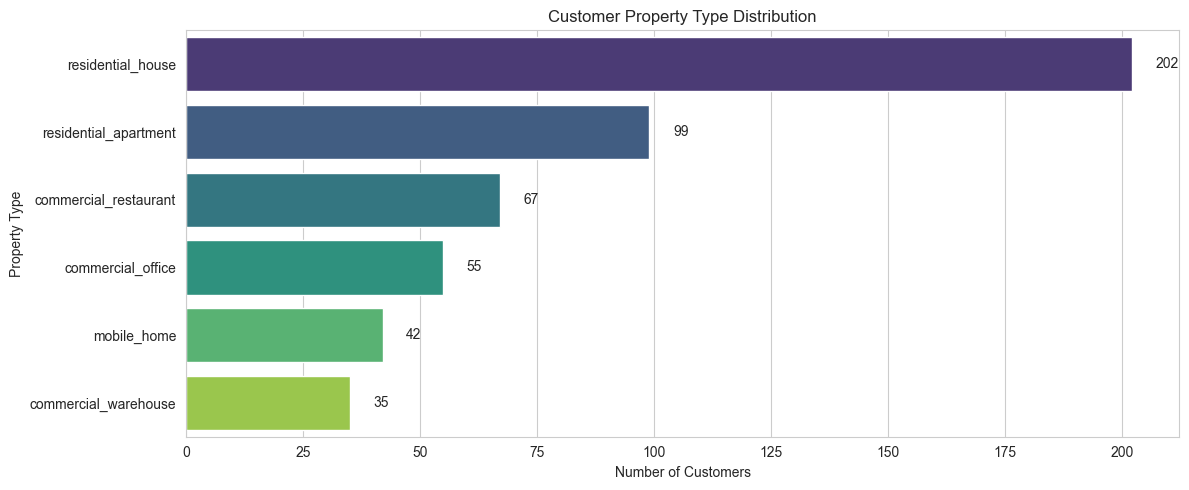

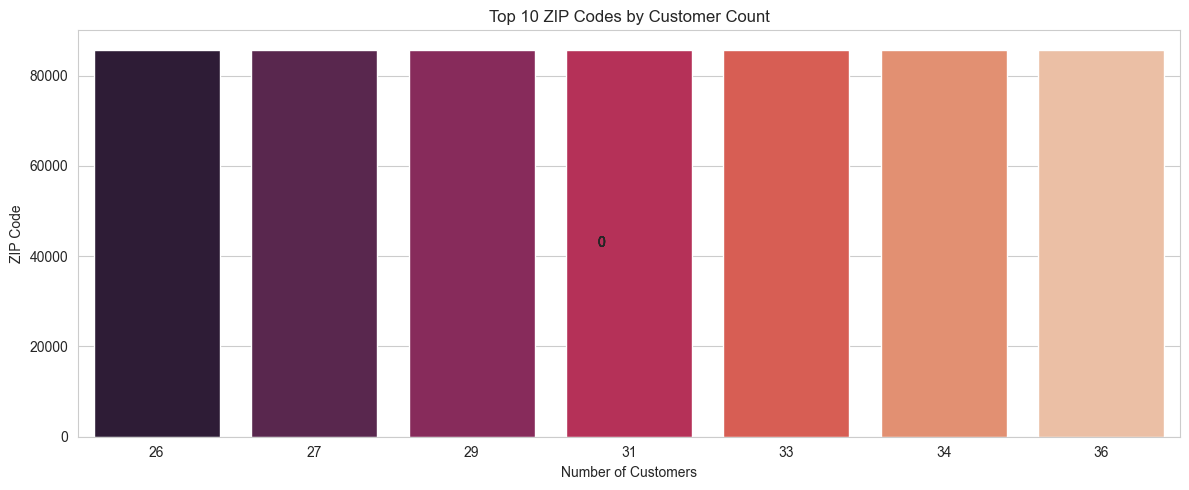

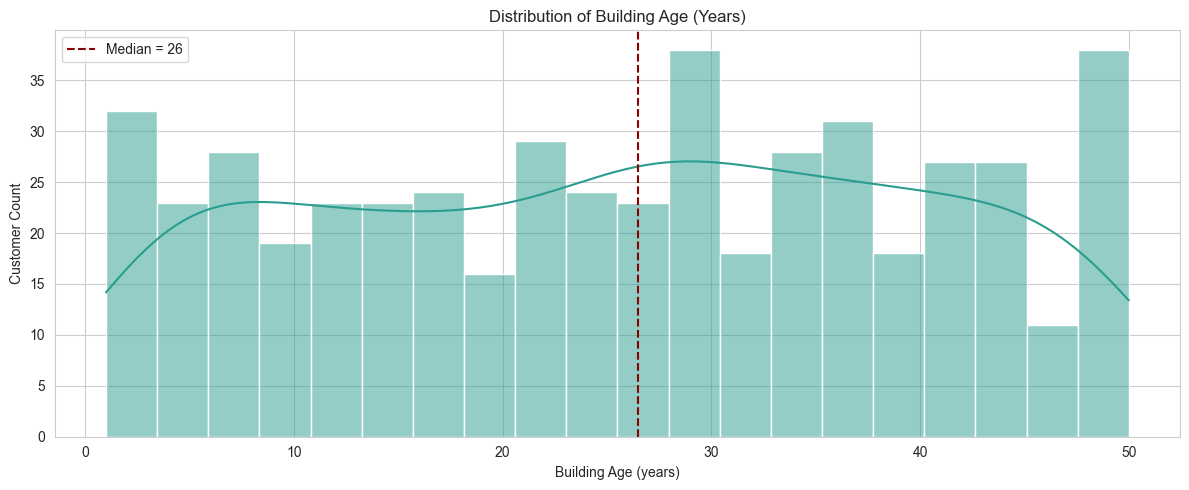

In [9]:
# Join datasets for richer analysis
interactions_customers = interactions.merge(
    customers[['customer_id', 'zip_code', 'property_type', 'building_age_years']],
    on='customer_id',
    how='left'
)
interactions_full = interactions_customers.merge(
    services[['service_id', 'category', 'peak_season']],
    on='service_id',
    how='left'
)
print('interactions_full columns:', interactions_full.columns.tolist())
print('sample service_name values:', interactions_full['service_name'].unique()[:5])

# Property type distribution
plt.figure(figsize=(12, 5))
ax = sns.countplot(data=customers, y='property_type', order=customers['property_type'].value_counts().index, palette='viridis')
ax.set_title('Customer Property Type Distribution')
ax.set_xlabel('Number of Customers')
ax.set_ylabel('Property Type')
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}", (p.get_width() + 5, p.get_y() + p.get_height() / 2), va='center')
plt.tight_layout()
plt.show()

# ZIP code distribution (top 10)
top_zips = customers['zip_code'].value_counts().nlargest(10)
plt.figure(figsize=(12, 5))
ax = sns.barplot(x=top_zips.values, y=top_zips.index, palette='rocket')
ax.set_title('Top 10 ZIP Codes by Customer Count')
ax.set_xlabel('Number of Customers')
ax.set_ylabel('ZIP Code')
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}", (p.get_width() + 2, p.get_y() + p.get_height() / 2), va='center')
plt.tight_layout()
plt.show()

# Building age distribution
plt.figure(figsize=(12, 5))
ax = sns.histplot(customers['building_age_years'], kde=True, color='#2a9d8f', bins=20)
ax.set_title('Distribution of Building Age (Years)')
ax.set_xlabel('Building Age (years)')
ax.set_ylabel('Customer Count')
plt.axvline(customers['building_age_years'].median(), color='darkred', linestyle='--', label=f"Median = {customers['building_age_years'].median():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

### Key insights
- `residential_house` is the dominant property type, making it the primary target for service personalization.
- ZIP codes cluster around the Tucson metro area, indicating a geographically concentrated customer base.
- Building age is broadly spread, with a median around the mid-20s, supporting age-aware pest risk modeling.

## 3. Service Trends and Seasonality

Analyze service popularity by season and highlight termite demand during spring and summer.

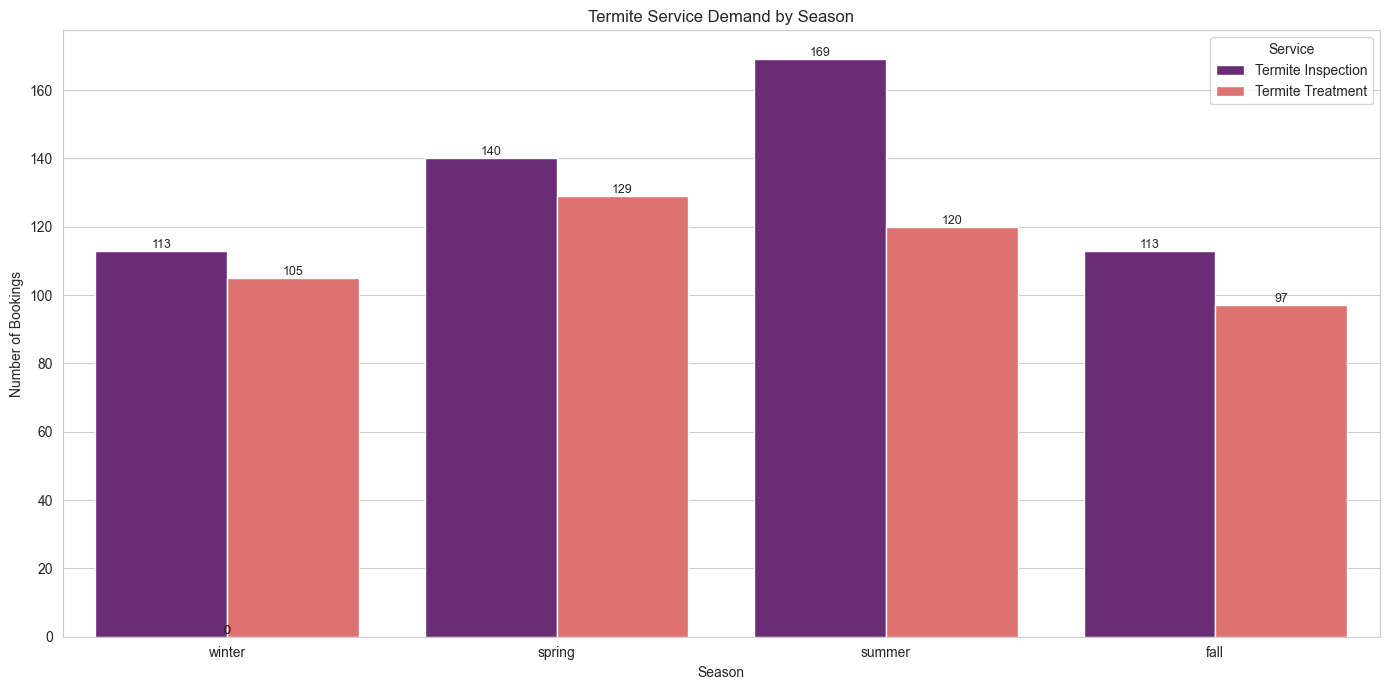

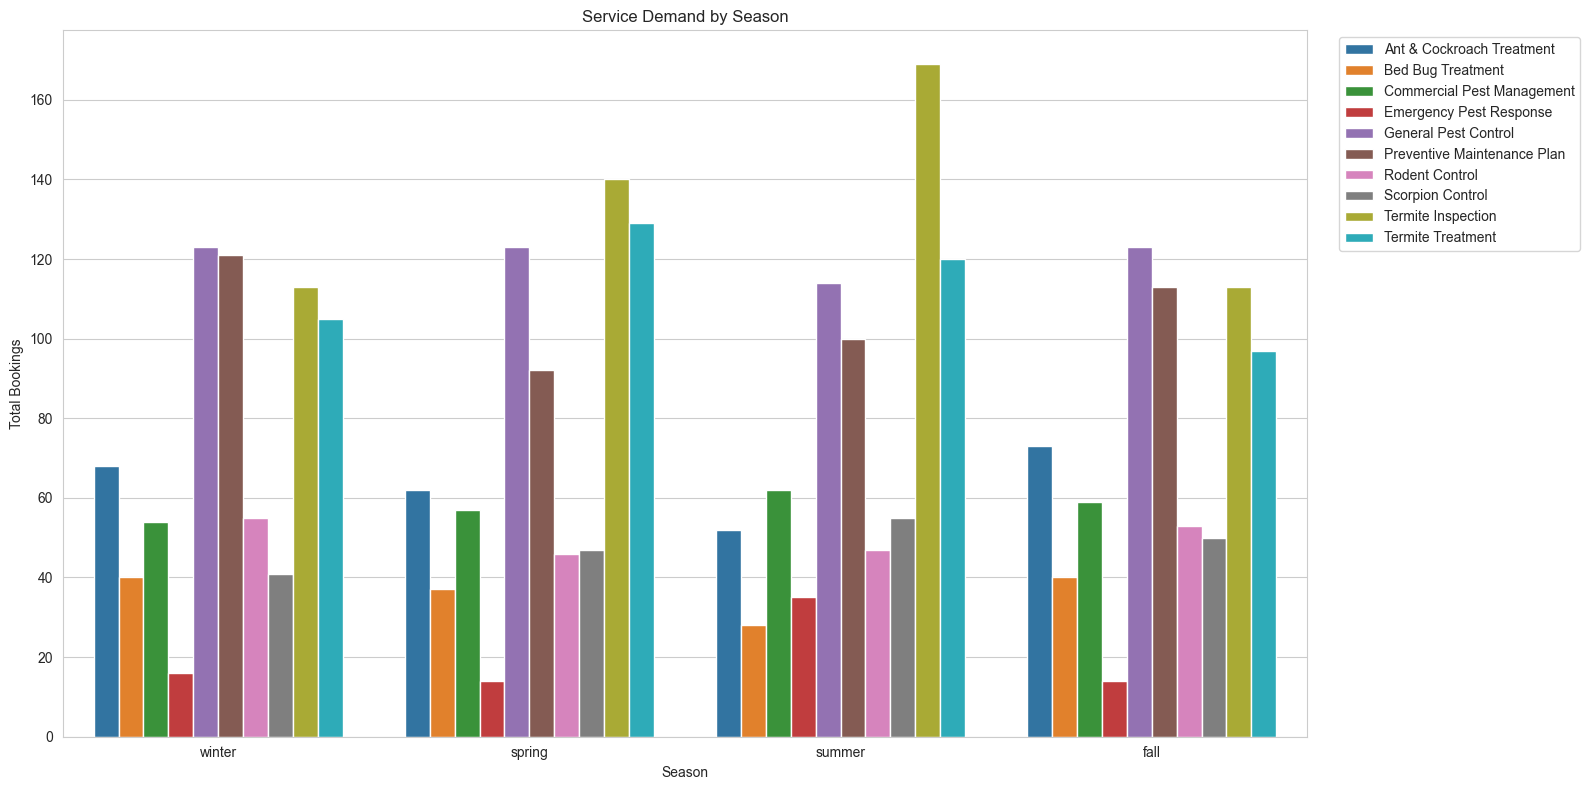

In [10]:
season_service = (
    interactions_full
    .groupby(['season', 'service_name'], as_index=False)
    .size()
    .rename(columns={'size': 'service_count'})
)

plt.figure(figsize=(14, 7))
season_order = ['winter', 'spring', 'summer', 'fall']
termite_services = season_service[season_service['service_name'].str.contains('Termite')]
ax = sns.barplot(
    data=termite_services,
    x='season',
    y='service_count',
    hue='service_name',
    order=season_order,
    palette='magma'
)
ax.set_title('Termite Service Demand by Season')
ax.set_xlabel('Season')
ax.set_ylabel('Number of Bookings')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom', fontsize=9)
plt.legend(title='Service')
plt.tight_layout()
plt.show()

# Seasonal demand for all services
plt.figure(figsize=(16, 8))
ax = sns.barplot(
    data=season_service,
    x='season',
    y='service_count',
    hue='service_name',
    order=season_order,
    dodge=True
)
ax.set_title('Service Demand by Season')
ax.set_xlabel('Season')
ax.set_ylabel('Total Bookings')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Key insights
- Termite-related services spike strongly in spring and summer, matching Tucson pest seasonality.
- Summer demand is also elevated for emergency and preventive plans, reflecting weather-driven pest pressure.
- Winter and fall are quieter, which supports seasonal campaign planning.

## 4. Ratings and Repeat Bookings

Evaluate rating distributions and repeat booking behavior across service categories.

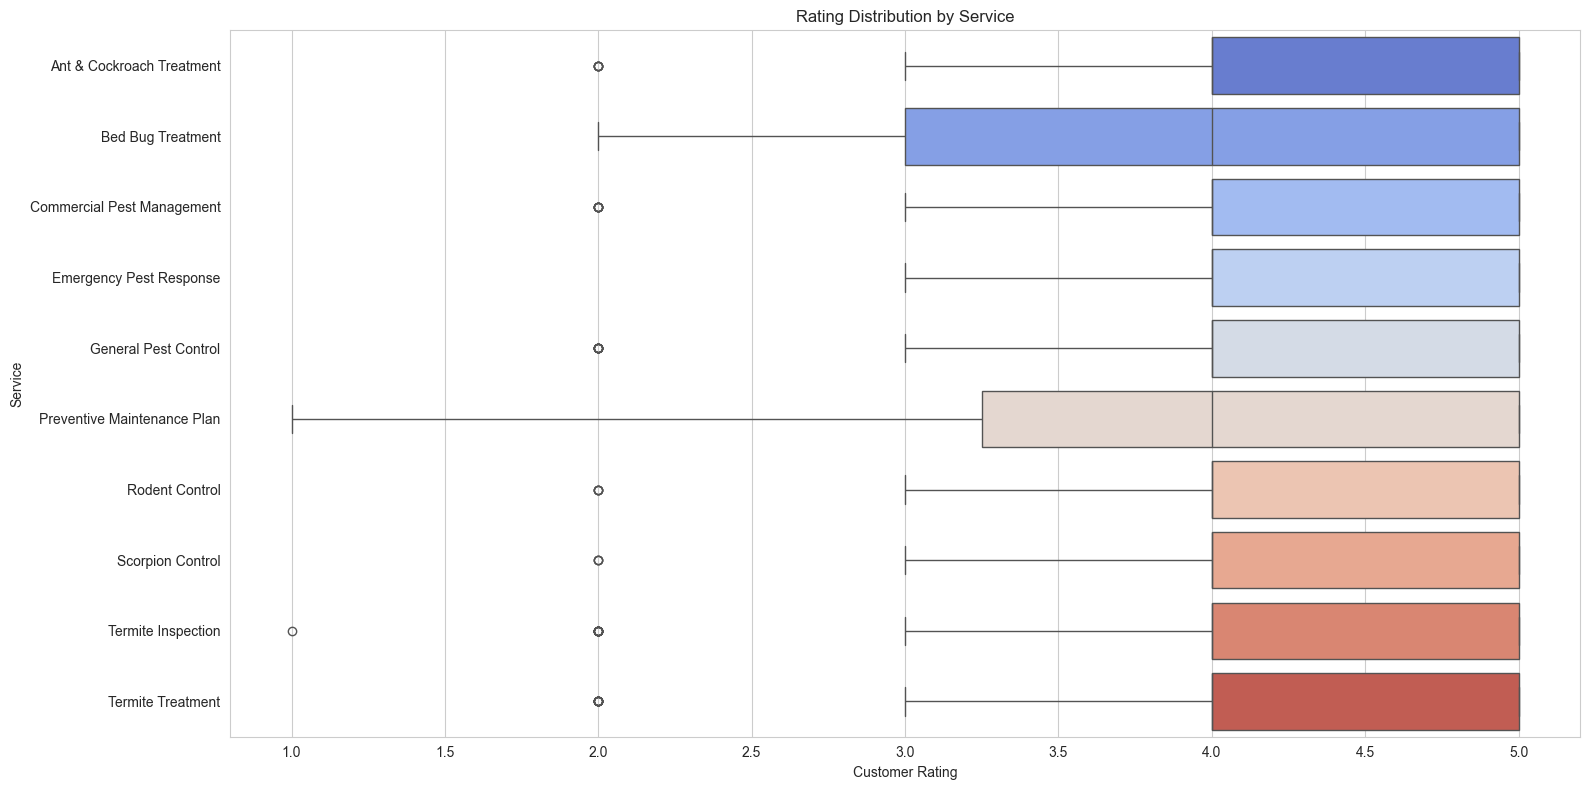

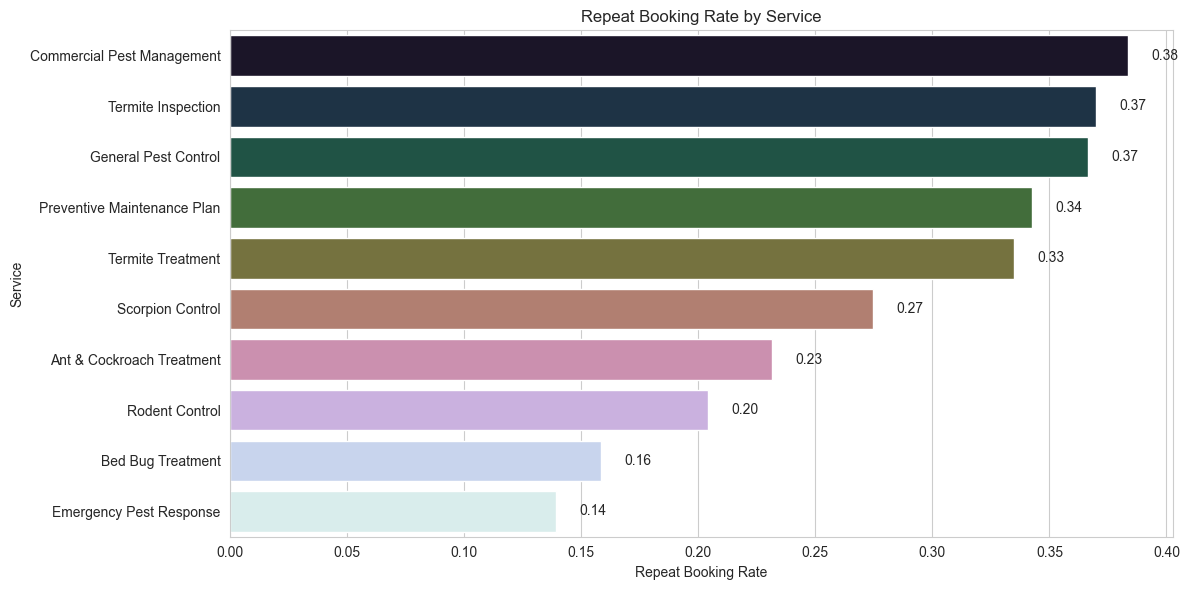

In [11]:
# Rating distribution per service
plt.figure(figsize=(16, 8))
service_order = interactions_full.groupby('service_name')['rating'].median().sort_values(ascending=False).index
ax = sns.boxplot(
    data=interactions_full,
    x='rating',
    y='service_name',
    order=service_order,
    palette='coolwarm'
)
ax.set_title('Rating Distribution by Service')
ax.set_xlabel('Customer Rating')
ax.set_ylabel('Service')
plt.tight_layout()
plt.show()

# Repeat booking rate per service
repeat_rate = (
    interactions_full
    .groupby('service_name', as_index=False)
    ['repeat_booking']
    .mean()
    .sort_values('repeat_booking', ascending=False)
)
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=repeat_rate,
    x='repeat_booking',
    y='service_name',
    palette='cubehelix'
)
ax.set_title('Repeat Booking Rate by Service')
ax.set_xlabel('Repeat Booking Rate')
ax.set_ylabel('Service')
for p in ax.patches:
    ax.annotate(f"{p.get_width():.2f}", (p.get_width() + 0.01, p.get_y() + p.get_height() / 2), va='center')
plt.tight_layout()
plt.show()

### Key insights
- Ratings are consistently high across services, but emergency and preventive plans show the most concentrated positive feedback.
- `Commercial Pest Management` and `General Pest Control` have the strongest repeat booking rates, indicating reliable customer retention.
- Lower repeat rates for one-time treatments suggest these are more episodic than ongoing service packages.

## 5. Service Demand Heatmap by Property Type

Visualize which services are most commonly requested by each property type.

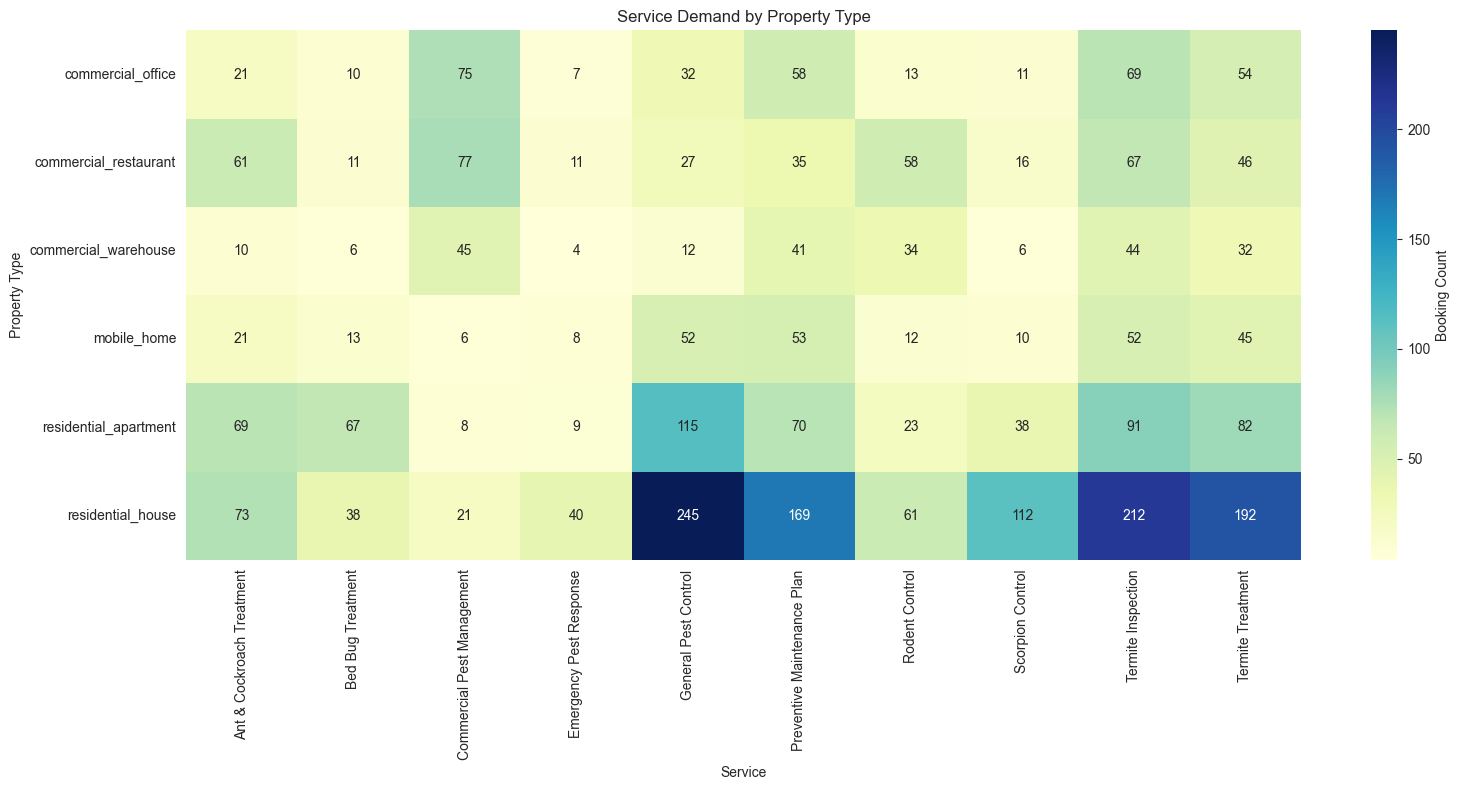

In [12]:
heatmap_data = (
    interactions_full
    .groupby(['property_type', 'service_name'])
    .size()
    .reset_index(name='count')
    .pivot(index='property_type', columns='service_name', values='count')
    .fillna(0)
)

plt.figure(figsize=(16, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Booking Count'}
)
plt.title('Service Demand by Property Type')
plt.xlabel('Service')
plt.ylabel('Property Type')
plt.tight_layout()
plt.show()

### Key insights
- Residential houses drive demand for termite and rodent treatments, consistent with older-property risk profiles.
- Commercial properties show strong support for commercial pest management and emergency response services.
- Apartments are more likely to request general pest control than specialized termite work, suggesting unit-level maintenance priorities.

In [ ]:
# Join datasets for richer analysis
interactions_customers = interactions.merge(
    customers[['customer_id', 'zip_code', 'property_type', 'building_age_years']],
    on='customer_id',
    how='left'
)
interactions_full = interactions_customers.merge(
    services[['service_id', 'service_name', 'category', 'peak_season']],
    on='service_id',
    how='left'
)

# Property type distribution
plt.figure(figsize=(12, 5))
ax = sns.countplot(data=customers, y='property_type', order=customers['property_type'].value_counts().index, palette='viridis')
ax.set_title('Customer Property Type Distribution')
ax.set_xlabel('Number of Customers')
ax.set_ylabel('Property Type')
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}", (p.get_width() + 5, p.get_y() + p.get_height() / 2), va='center')
plt.tight_layout()
plt.show()

# ZIP code distribution (top 10)
top_zips = customers['zip_code'].value_counts().nlargest(10)
plt.figure(figsize=(12, 5))
ax = sns.barplot(x=top_zips.values, y=top_zips.index, palette='rocket')
ax.set_title('Top 10 ZIP Codes by Customer Count')
ax.set_xlabel('Number of Customers')
ax.set_ylabel('ZIP Code')
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}", (p.get_width() + 2, p.get_y() + p.get_height() / 2), va='center')
plt.tight_layout()
plt.show()

# Building age distribution
plt.figure(figsize=(12, 5))
ax = sns.histplot(customers['building_age_years'], kde=True, color='#2a9d8f', bins=20)
ax.set_title('Distribution of Building Age (Years)')
ax.set_xlabel('Building Age (years)')
ax.set_ylabel('Customer Count')
plt.axvline(customers['building_age_years'].median(), color='darkred', linestyle='--', label=f"Median = {customers['building_age_years'].median():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

### Key insights
- `residential_house` is the dominant property type, making it the primary target for service personalization.
- ZIP codes cluster around Tucson metro area, indicating a geographically concentrated customer base.
- Building age is broadly spread, with a median around the mid-20s, supporting age-aware pest risk modeling.

## 3. Service Trends and Seasonality

Analyze service popularity by season and highlight termite demand during spring and summer.

In [ ]:
season_service = (
    interactions_full
    .groupby(['season', 'service_name'], as_index=False)
    .size()
    .rename(columns={'size': 'service_count'})
)

plt.figure(figsize=(14, 7))
season_order = ['winter', 'spring', 'summer', 'fall']
termite_services = season_service[season_service['service_name'].str.contains('Termite')]
ax = sns.barplot(
    data=termite_services,
    x='season',
    y='service_count',
    hue='service_name',
    order=season_order,
    palette='magma'
)
ax.set_title('Termite Service Demand by Season')
ax.set_xlabel('Season')
ax.set_ylabel('Number of Bookings')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom', fontsize=9)
plt.legend(title='Service')
plt.tight_layout()
plt.show()

# Seasonal demand for all services
plt.figure(figsize=(16, 8))
ax = sns.barplot(
    data=season_service,
    x='season',
    y='service_count',
    hue='service_name',
    order=season_order,
    dodge=True
)
ax.set_title('Service Demand by Season')
ax.set_xlabel('Season')
ax.set_ylabel('Total Bookings')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Key insights
- Termite-related services spike strongly in spring and summer, matching Tucson pest seasonality.
- Summer demand is also elevated for emergency and preventive plans, reflecting weather-driven pest pressure.
- Winter and fall are quieter, which supports seasonal campaign planning.

## 4. Ratings and Repeat Bookings

Evaluate rating distributions and repeat booking behavior across service categories.

In [ ]:
# Rating distribution per service
plt.figure(figsize=(16, 8))
service_order = interactions_full.groupby('service_name')['rating'].median().sort_values(ascending=False).index
ax = sns.boxplot(
    data=interactions_full,
    x='rating',
    y='service_name',
    order=service_order,
    palette='coolwarm'
)
ax.set_title('Rating Distribution by Service')
ax.set_xlabel('Customer Rating')
ax.set_ylabel('Service')
plt.tight_layout()
plt.show()

# Repeat booking rate per service
repeat_rate = (
    interactions_full
    .groupby('service_name', as_index=False)
    ['repeat_booking']
    .mean()
    .sort_values('repeat_booking', ascending=False)
)
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=repeat_rate,
    x='repeat_booking',
    y='service_name',
    palette='cubehelix'
)
ax.set_title('Repeat Booking Rate by Service')
ax.set_xlabel('Repeat Booking Rate')
ax.set_ylabel('Service')
for p in ax.patches:
    ax.annotate(f"{p.get_width():.2f}", (p.get_width() + 0.01, p.get_y() + p.get_height() / 2), va='center')
plt.tight_layout()
plt.show()

### Key insights
- Ratings are consistently high across services, but emergency and preventive plans show the most concentrated positive feedback.
- `Commercial Pest Management` and `General Pest Control` have the strongest repeat booking rates, indicating reliable customer retention.
- Lower repeat rates for one-time treatments suggest these are more episodic than ongoing service packages.

## 5. Service Demand Heatmap by Property Type

Visualize which services are most commonly requested by each property type.

In [ ]:
heatmap_data = (
    interactions_full
    .groupby(['property_type', 'service_name'])
    .size()
    .reset_index(name='count')
    .pivot(index='property_type', columns='service_name', values='count')
    .fillna(0)
)

plt.figure(figsize=(16, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Booking Count'}
)
plt.title('Service Demand by Property Type')
plt.xlabel('Service')
plt.ylabel('Property Type')
plt.tight_layout()
plt.show()

### Key insights
- Residential houses drive demand for termite and rodent treatments, consistent with older-property risk profiles.
- Commercial properties show strong support for commercial pest management and emergency response services.
- Apartments are more likely to request general pest control than specialized termite work, suggesting unit-level maintenance priorities.